# Baseline Neural Network

This notebook builds and evaluates the first baseline neural network for multiclass recruitment status classification.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [22]:
np.random.seed(42)
tf.random.set_seed(42)

In [23]:
data_path = Path("../data/Datasets.xlsx")

df = pd.read_excel(
    data_path,
    sheet_name="Recruitment"
)

X = df.drop(columns=["Candidate_ID", "Status"])
y = df["Status"]

In [24]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Hired' 'Pending' 'Rejected']


In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [26]:
numerical_features = [
    "Experience",
    "Tech_Score",
    "Interview"
]

categorical_features = [
    "Position"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [28]:
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Train: (140, 6)
Validation: (30, 6)
Test: (30, 6)


In [29]:
input_size = X_train_processed.shape[1]

print("Number of input features:", input_size)

Number of input features: 6


In [30]:
baseline_model = Sequential([
    tf.keras.Input(shape=(input_size,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

In [31]:
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803 (3.14 KB)

 Trainable params: 803 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
history = baseline_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3857 - loss: 1.0758 - val_accuracy: 0.3667 - val_loss: 1.0789
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3929 - loss: 1.0386 - val_accuracy: 0.3333 - val_loss: 1.0434
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3857 - loss: 1.0084 - val_accuracy: 0.2333 - val_loss: 1.0112
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4286 - loss: 0.9801 - val_accuracy: 0.3333 - val_loss: 0.9818
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4929 - loss: 0.9525 - val_accuracy: 0.4000 - val_loss: 0.9521
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5786 - loss: 0.9247 - val_accuracy: 0.4000 - val_loss: 0.9228
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6286 - loss: 0.8960 - val_accuracy: 0.4667 - val_loss: 0.8938
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6571 - loss: 0.8667 - val_accuracy: 0.5333 - val_loss: 0.8653
Epoch 9/100

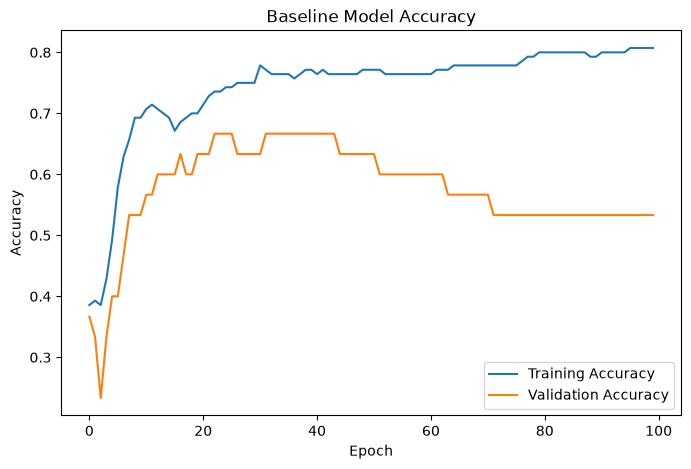

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

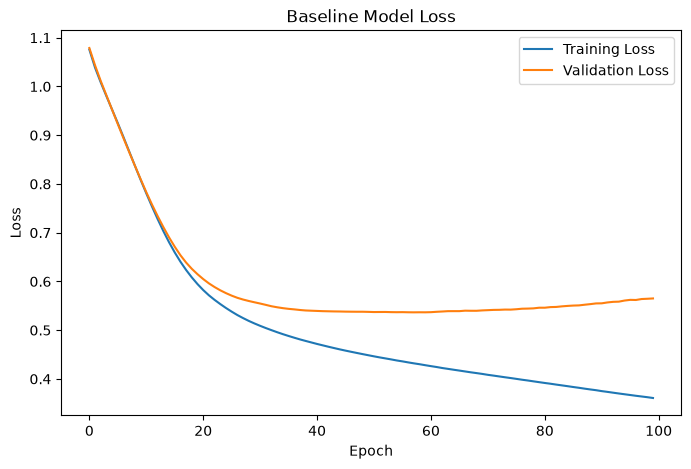

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
val_loss, val_accuracy = baseline_model.evaluate(
    X_val_processed,
    y_val,
    verbose=0
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss: 0.5650976300239563
Validation Accuracy: 0.5333333611488342


In [37]:
val_probabilities = baseline_model.predict(X_val_processed)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

val_predictions[:10]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


array([0, 0, 1, 1, 2, 1, 2, 2, 0, 2])

In [38]:
print(
    classification_report(
        y_val,
        val_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       Hired       1.00      1.00      1.00         9
     Pending       0.30      0.30      0.30        10
    Rejected       0.36      0.36      0.36        11

    accuracy                           0.53        30
   macro avg       0.55      0.55      0.55        30
weighted avg       0.53      0.53      0.53        30



In [39]:
cm = confusion_matrix(
    y_val,
    val_predictions
)

print(cm)

[[9 0 0]
 [0 3 7]
 [0 7 4]]


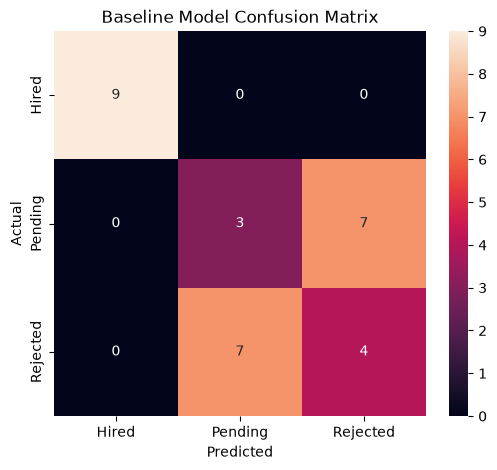

In [40]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Baseline Model

Architecture:

- Input layer
- Dense layer: 32 neurons, ReLU
- Dense layer: 16 neurons, ReLU
- Output layer: 3 neurons, Softmax

Training configuration:

- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Epochs: 100
- Batch size: 16

The baseline model was trained without regularization so that its training and validation behavior could be observed before applying overfitting-prevention techniques.